<a href="https://colab.research.google.com/github/yangkeyin/Resume-Algorithms-Lab/blob/main/01_%E6%89%8B%E6%8E%A8_RoPE_%E7%9A%84%E5%A4%8D%E6%95%B0%E5%BD%A2%E5%BC%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import torch
import torch.nn as nn
import numpy as np

## 为什么需要它？（没有它会怎么样）
在 RoPE 出现之前，我们主要用两种位置编码：绝对位置编码（像编号 1, 2, 3...）和相对位置编码。

没有它的痛苦： 传统的绝对位置编码（如 BERT 的 Learnable Embedding 或 Transformer 原生的 Sinusoidal）就像给每个座位贴了固定标签。一旦测试时的句子比训练时长，模型就“懵”了，因为它没见过第 2049 个标签。

核心诉求： 我们希望模型不只是记住“我在第几个”，而是能感知到“我和你之间隔了几个”。这就是平移不变性。

In [11]:
# 为了让你能运行，我们模拟一些基础数据
batch_size = 1  # 每次处理一个句子
seq_len = 5     # 句子的长度（5个单词）
d_model = 8     # 每个词向量的长度（为了简单，我们设为8）

# little repository
abs_posembedding = nn.Embedding(10, d_model)
# 相对位置通常是在算“注意力得分”时加进去的
# 假设距离范围是 -10 到 10，我们要存 21 种可能的距离情况
rel_embedding = nn.Embedding(21, 1) # 存偏置项 (Bias)
vecs = torch.randn(batch_size, seq_len, d_model)

In [35]:
print(abs_posembedding(torch.tensor(3)))

tensor([-1.2667,  0.2339, -0.2113,  0.4443,  0.9340, -0.0868, -0.3366,  0.5814],
       grad_fn=<EmbeddingBackward0>)


In [39]:
# 绝对位置编码
def absolute_pos_encoding(vec):
  # posembedding is a excel and store 0-2048 labels
  positions = torch.arange(seq_len)
  pos_label = abs_posembedding(positions) # if pos out of 2048, the script will error

  # simply add
  return vec + pos_label
# 相对位置编码
print("绝对位置编码后的形状", absolute_pos_encoding(vecs).shape)

def relative_pos_encoding(vec_m, vec_n, m, n):
  # calculate score
  score = torch.dot(vec_m, vec_n)

  dist = torch.tensor(m - n + 10)
  rel_bias = rel_embedding(dist)

  return score + rel_bias

# calculate the relation between first and third word
word_1 = vecs[0,1]
print(word_1.shape)
word_2 = vecs[0,3]
score = relative_pos_encoding(word_1, word_2, 1, 3)
print(f"第1个词和第3个词的相对位置得分: {score.item():.4f}")


绝对位置编码后的形状 torch.Size([1, 5, 8])
torch.Size([8])
第1个词和第3个词的相对位置得分: -1.3188


## 手推复数形式：它是如何解决的？
RoPE 的天才之处在于：它把位置信息转化为了向量在空间中的“旋转”。核心思想假设我们有两个向量 $q$ 和 $k$，我们希望它们的内积只取决于它们的相对距离 $m-n$。苏剑林老师和团队通过严谨的数学推导发现，这可以通过复数乘法完美实现。复数形式推导我们将二维向量 $(x_1, x_2)$ 看作复数 $z = x_1 + i x_2$。位置嵌入： 对于位置 $m$ 的向量 $q$，我们给它乘上一个旋转算子 $e^{im\theta}$。公式表示：$$f(q, m) = q \cdot e^{im\theta}$$这里 $\theta$ 是一个预设的频率常数。内积特性（为什么有效）：当我们计算位置 $m$ 的 $q$ 和位置 $n$ 的 $k$ 的点积时，在复数空间相当于计算：$$\langle f(q, m), f(k, n) \rangle = \text{Re}[q \cdot e^{im\theta} \cdot (k \cdot e^{in\theta})^*]$$$$\langle f(q, m), f(k, n) \rangle = \text{Re}[q \bar{k} \cdot e^{i(m-n)\theta}]$$结论： 看！最后的指数项变成了 $(m-n)\theta$。这意味着，无论 $m$ 和 $n$ 在哪里，只要它们距离不变，注意力分数就保持一致。它巧妙地用绝对位置的旋转实现了相对位置的表达。

### 总代码验证

In [45]:
# RoPE: 把位置信息转化为了向量空间中的旋转
# 内积只取决于相对距离m-n
def rope_2d(vec, pos, theta=np.pi/6):
  x = vec[0]
  y = vec[1]

  angle = pos * theta

  x_rotated = x * np.cos(angle) - y * np.sin(angle)
  y_rotated = x * np.sin(angle) + y * np.cos(angle)

  return np.array([x_rotated, y_rotated])

def new_dot_rope(vec_m, vec_n, m, n):
  # assume vector input is two dimensions
  f_vecm = rope_2d(vec_m, m)
  f_vecn = rope_2d(vec_n, n)
  return np.dot(f_vecm, f_vecn)

# validata
v1 = np.array([1.0, 0.0])
v2 = np.array([0.5, 0.5])
# 情况 A：位置是 (1, 2)，距离是 1
score_a = new_dot_rope(v1, v2, 1, 2)

# 情况 B：位置是 (100, 101)，距离也是 1
score_b = new_dot_rope(v1, v2, 100, 101)

print(f"位置(1,2)的得分: {score_a:.4f}")
print(f"位置(100,101)的得分: {score_b:.4f}")
print("结论：你看，不管位置在哪，只要距离是1，得分完全一样！")

位置(1,2)的得分: 0.1830
位置(100,101)的得分: 0.1830
结论：你看，不管位置在哪，只要距离是1，得分完全一样！


###  为什么 $f(q, n) = q \cdot e^{in\theta}$ 等于 将向量拆解为x和y，并左乘二维旋转矩阵
旋转矩阵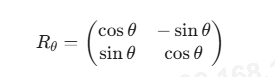


In [43]:
# 假设词向量是 [3, 4]，位置是 n=2
x, y = 3, 4
n = 2
theta = 0.5

# 1. 把向量包装成复数 z = 3 + 4j
z = complex(x, y)

# 2. 计算旋转算子 e^(i * n * theta)
# 根据著名的欧拉公式：e^(i*A) = cos(A) + i*sin(A)
angle = n * theta
rotation_operator = complex(np.cos(angle), np.sin(angle))

# 3. 执行乘法：z_new = z * rotation_operator
z_new = z * rotation_operator

# 咱们手动拆解一下这个乘法 (a+bi)(c+di) = (ac - bd) + (ad + bc)i
# 对应到我们的变量：
# a = x,  b = y
# c = cos(angle), d = sin(angle)

new_x = x * np.cos(angle) - y * np.sin(angle)  # 这不就是代码里的 x_rotated 吗！
new_y = x * np.sin(angle) + y * np.cos(angle)  # 这不就是代码里的 y_rotated 吗！

print(f"复数直接乘的结果: {z_new}")
print(f"用代码公式算的结果: [{new_x}, {new_y}]")

复数直接乘的结果: (-1.7449770216271667+4.685622177896248j)
用代码公式算的结果: [-1.7449770216271667, 4.685622177896248]


### $$\langle f(q, m), f(k, n) \rangle = \text{Re}[q \cdot e^{im\theta} \cdot (k \cdot e^{in\theta})^*]$$$$\langle f(q, m), f(k, n) \rangle = \text{Re}[q \bar{k} \cdot e^{i(m-n)\theta}]$$

In [54]:
import numpy as np

# 1. 准备基础数据
m, n = 100, 98      # 位置
theta = 0.1         # 频率常数

# 假设原始的词向量（复数形式）
# q 是搜索词，k 是被搜词
q = complex(1.0, 2.0)
k = complex(3.0, 4.0)
q_vec = np.array([q.real, q.imag])
k_vec = np.array([k.real, k.imag])

# 2. 计算 RoPE 变身后的向量 (即 f(q, m) 和 f(k, n))
# 也就是给它们各自乘上属于自己位置的旋转角度
f_q_m = q * np.exp(1j * m * theta)
f_k_n = k * np.exp(1j * n * theta)

# 3. 重点来了！验证公式：
# 左边：变身后向量的点积（在复数里，点积 = 第一个词 * 第二个词的共轭的实部）
left_side = np.real(f_q_m * np.conj(f_k_n))

# 右边：原始向量相乘 * 相对距离的角度
# 注意看这里：q * np.conj(k) 就是公式里的 qk拔
right_side = np.real((q * np.conj(k)) * np.exp(1j * (m - n) * theta))

# 4. 打印结果
print(f"直接点积：{np.dot(q_vec, k_vec):.4f}")
print(f"变身后直接点积的结果: {left_side:.4f}")
print(f"用'相对距离公式'算的结果: {right_side:.4f}")

直接点积：11.0000
变身后直接点积的结果: 10.3834
用'相对距离公式'算的结果: 10.3834


## 还存在什么问题？
虽然 RoPE 接近完美，但在实际工业界应用中，它依然面临几个挑战：远程衰减的局限性： 理论上 RoPE 随着距离拉长，关联性会衰减。但如果 $\theta$ 设置不当，模型在极长文本下（比如 128k 甚至更长）会出现“注意力弥散”，导致模型记不住太远的信息。外推难题（Out-of-Distribution）： 虽然它比绝对位置编码好，但如果你训练时只用了 4k 长度，直接去跑 32k，旋转的角度会超出模型见过的范围。目前的解决方法： 衍生出了 PI (Position Interpolation)、NTK-aware RoPE 等技术，通过“挤压”旋转角度来适应更长的文本。计算开销： 相比简单的加法（Absolute），RoPE 需要进行逐元素的旋转计算（三角函数乘加），虽然开销不算巨大，但在推理优化（如 Flash Attention）时需要专门的算子融合处理。

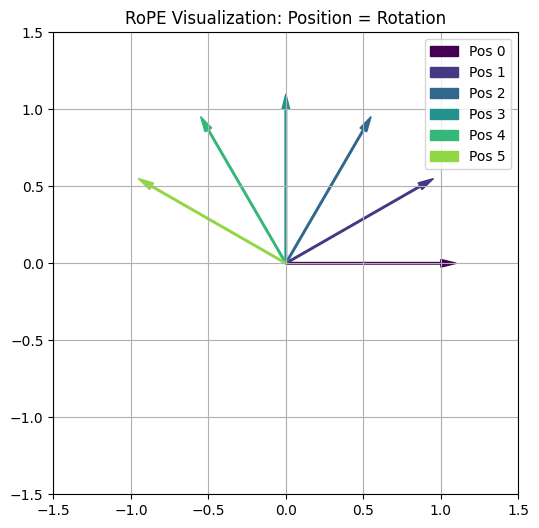

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rope_rotation():
    # 1. 定义一个初始向量 (单词的含义)
    # 比如向量 [1, 0]，代表这个词原本的特征
    vec = np.array([1.0, 0.0])

    # 2. 定义旋转角度 theta (Base)
    # 假设每过一个位置，转动 30 度 (pi/6)
    theta = np.pi / 6

    # 3. 模拟不同位置 (m = 0, 1, 2, 3...)
    positions = range(6) # 看前6个位置

    plt.figure(figsize=(6, 6))

    for m in positions:
        # --- 这里就是那复杂的复数推导对应的真实动作 ---
        # 旋转 m * theta 角度
        angle = m * theta

        # 旋转矩阵 (这就是那堆 cos/sin 的本质)
        rotation_matrix = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])

        # 旋转后的向量
        rotated_vec = rotation_matrix @ vec

        # --- 画出来 ---
        plt.arrow(0, 0, rotated_vec[0], rotated_vec[1],
                  head_width=0.05, head_length=0.1,
                  color=plt.cm.viridis(m/6), width=0.01,
                  label=f'Pos {m}')

    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.title("RoPE Visualization: Position = Rotation")
    plt.show()

plot_rope_rotation()